# **--- GETAROUND PROJECT (delay analysis)---** #

## **1. Libraries import** ##

In [77]:
import pandas as pd
import numpy as np
import os
import json


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.stats import chi2_contingency

## **2. Data import and first observations** ##

In [38]:
# Dataset import
raw_df=pd.read_excel("../DATA/raw_data/get_around_delay_analysis.xlsx")
raw_df.head()

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [39]:
# Size of the dataset
raw_df.shape

(21310, 7)

In [40]:
# Statistical information
raw_df.describe(include="all")

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.000000,21310.000000,21310,21310,16346.000000,1841.000000,1841.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,mobile,ended,NaN,NaN,NaN
freq,NaN,NaN,17003,18045,NaN,NaN,NaN
mean,549712.880338,350030.603426,NaN,NaN,59.701517,550127.411733,279.288430
std,13863.446964,58206.249765,NaN,NaN,1002.561635,13184.023111,254.594486
min,504806.000000,159250.000000,NaN,NaN,-22433.000000,505628.000000,0.000000
25%,540613.250000,317639.000000,NaN,NaN,-36.000000,540896.000000,60.000000
50%,550350.000000,368717.000000,NaN,NaN,9.000000,550567.000000,180.000000
75%,560468.500000,394928.000000,NaN,NaN,67.000000,560823.000000,540.000000


In [41]:
# Check for duplicates
raw_df.duplicated().any() 

False

In [42]:
# Main information on the dataset
raw_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


We can observe the presence of missing values for 3 variables : 
- `delay_at_checkout_in_minutes`,
- `previous_ended_rental_id`,
- `time_delta_with_previous_rental_in_minutes`


In [43]:
# Check for the pourcentage of missing values per column (in %)
total_nb_rentals=raw_df.shape[0]
round(100*raw_df.isna().sum()/total_nb_rentals,2)

rental_id                                      0.00
car_id                                         0.00
checkin_type                                   0.00
state                                          0.00
delay_at_checkout_in_minutes                  23.29
previous_ended_rental_id                      91.36
time_delta_with_previous_rental_in_minutes    91.36
dtype: float64

We can observe that the proportion of missing values for the variables `previous_ended_rental_id` and `time_delta_with_previous_rental_in_minutes` is very high (91.36%) and identical. This suggests that the missingness may be related either to a lack of available data or to cases where the rental corresponds to the first usage of the car.

Note: We do not have any temporal context here (for example, whether the rentals are recorded per day or over a specific time period), which limits further interpretation. 

## **3. Missing data analysis (`previous_ended_rental_id` and `time_delta`)** ##

Let's first study the missing values for the variables `previous_ended_rental_id` and `time_delta_with_previous_rental_in_minutes`. Here is our hypothesis :  
**Missing data for these variable is related to a first rental of a given car.**

### **3.1. Consistency of missing data** ###

To verify this hypothesis, we are going to check the following consistency rules:

- No previous rental: both variables should be missing simultaneously.
- Previous rental exists: both variables should be populated.

In other words, missingness should be consistent across the two columns.

In [44]:
# Conditions
both_null = raw_df['previous_ended_rental_id'].isnull() & raw_df['time_delta_with_previous_rental_in_minutes'].isnull()
both_filled = raw_df['previous_ended_rental_id'].notnull() & raw_df['time_delta_with_previous_rental_in_minutes'].notnull()
only_prev_null = raw_df['previous_ended_rental_id'].isnull() & raw_df['time_delta_with_previous_rental_in_minutes'].notnull()
only_delta_null = raw_df['previous_ended_rental_id'].notnull() & raw_df['time_delta_with_previous_rental_in_minutes'].isnull()

# Summary table
coherence_check = pd.DataFrame({
    'Scenario': [
        'Both NULL (consistent)',
        'Both FILLED (consistent)', 
        'Only previous_rental NULL (inconsistent)',
        'Only time_delta NULL (inconsistent)'
    ],
    'Count': [
        both_null.sum(),
        both_filled.sum(),
        only_prev_null.sum(),
        only_delta_null.sum()
    ],
    'Percentage': [
        (both_null.sum() / len(raw_df) * 100).round(2),
        (both_filled.sum() / len(raw_df) * 100).round(2),
        (only_prev_null.sum() / len(raw_df) * 100).round(2),
        (only_delta_null.sum() / len(raw_df) * 100).round(2)
    ]
})

coherence_check


,Scenario,Count,Percentage
0,Both NULL (consistent),19469,91.36
1,Both FILLED (consistent),1841,8.64
2,Only previous_rental NULL (inconsistent),0,0.00
3,Only time_delta NULL (inconsistent),0,0.00


Missing values are consistent across both columns, which indicates that they are associated with the absence of a previous rental during the observed period rather than with data quality issues. As a result, the analysis should focus on cases where a car has multiple consecutive rentals, as these are the situations in which delays can propagate and have an impact.

### **3.2. Number of missing data according to the number of rentals** ###

**_3.2.1. Separating cars according to their number of rentals_**

Let's now create 2 groups to devide the cars according to the number of rentals over the period: 
- first group: Cars with one rental only,
- second group: Cars with more than one rental.

In [45]:
# Numbers of cars in the dataset
total_nb_car=raw_df['car_id'].nunique()
print(f"There is a total of {total_nb_car} cars in the dataset.")

There is a total of 8143 cars in the dataset.


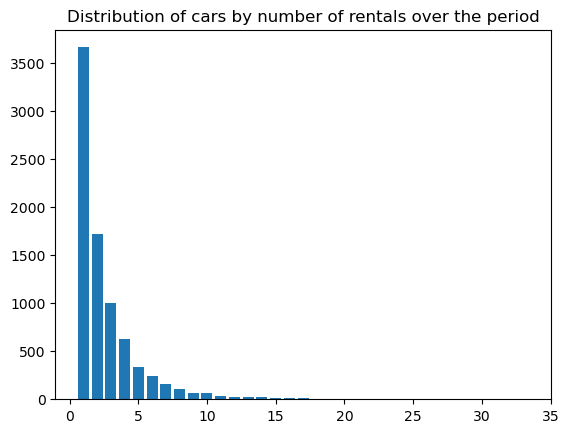

In [46]:
# Count rentals per car
nb_rentals_per_car = raw_df.groupby('car_id').size()
count_per_nb_rental = nb_rentals_per_car.value_counts()

plt.figure()
plt.bar(count_per_nb_rental.index,count_per_nb_rental.values)
plt.title("Distribution of cars by number of rentals over the period")
plt.show()

In [47]:
# Create first group (cars rented once only) :
cars_one_rental_ids = nb_rentals_per_car[nb_rentals_per_car == 1].index
nb_cars_one_rental=cars_one_rental_ids.nunique()
cars_one_rental_df=raw_df[raw_df["car_id"].isin(cars_one_rental_ids)]

print(f"Number of cars with only one rental : {nb_cars_one_rental}.\nThis represents {round((100*cars_one_rental_ids.nunique()/total_nb_car),2)}% of all cars.")

Number of cars with only one rental : 3659.
This represents 44.93% of all cars.


In [48]:
# Create second group (cars rented more than once) :
cars_several_rentals_ids = nb_rentals_per_car[nb_rentals_per_car > 1].index
nb_cars_several_rentals=cars_several_rentals_ids.nunique()
cars_several_rentals_df=raw_df[raw_df["car_id"].isin(cars_several_rentals_ids)]

print(f"Number of cars with several rentals : {nb_cars_several_rentals}.\nThis represents {round((100*cars_several_rentals_ids.nunique()/total_nb_car),2)}% of all cars.")

Number of cars with several rentals : 4484.
This represents 55.07% of all cars.


**Out of all cars in the dataset:** 

**- 44,93% have been rented only once over the period of time covered by the dataset,**

**- 55,07% have been rented more than once.**

**_3.2.2. Number of missing values in `previous_ended_rental_id` column according to how many times the car has been rented_**

In [49]:
# Total number of NaN for the variable 'previous_ended_rental_id' in the dataset (all rentals of cars with no previous rentals)
total_nb_nan_prev_rental=raw_df['previous_ended_rental_id'].isna().sum()

In [50]:
# Cars with only one rental: all the "previous_ended_rental_id" should be NaN
nb_nan_one_rental=cars_one_rental_df['previous_ended_rental_id'].isna().sum()
nb_nan_one_rental==nb_cars_one_rental

True

All cars that have been rented only once have 'NaN' values for the `previous_ended_rental_id` variable. Now let's check if cars with more than one rental, have exactly one 'NaN' for that variable. Despite the fact that we do not have chronological information, we can suppose that it would correspond to the first rental of the car.

In [51]:
# Cars with more than one rental: they should have exactly one NaN value for the "previous_ended_rental_id" variable corresponding to the first rental of consecutive rentals.
nb_nan_several_rentals = cars_several_rentals_df['previous_ended_rental_id'].isna().sum()

The total amount of NaN  for the variable `previous_ended_rental_id` correspond to all rentals without previous rentals. It is divided into:
- first rentals of cars that are rented only once,
- first rentals of cars that are rented several times.
It means that `nb_nan_one_rental` + `nb_nan_several_rentals` sould be equal to `total_nb_nan_prev_rental`. Let's check that : 

In [52]:
nb_nan_one_rental + nb_nan_several_rentals==total_nb_nan_prev_rental

True

Cars that have been rented more than once have exactly one NaN values in the `previous_ended_rental_id` column. We can thus validate our hypothesis: missing data for the variable `prevous_ended_rental_id` correspond to first rentals of: 
- cars with only one rental in total,
- cars with more than one rental (first rental of a chain of rentals).

To assess the impact of delays on cancellations, we focus on the 55.07% of cars that are involved in multiple successive rentals.
For these vehicles, we exclude the first rental in each sequence, as it cannot be affected by a prior delay.

The remaining rentals—those exposed to a potential knock-on effect from previous delays—represent 8.64% of all rentals. These rentals are therefore considered “at risk.”

In [53]:
# Select and save all rows with an "at risk" rental_id: 
risky_rentals_df=raw_df[both_filled] # we select rows with non NaN values for the previous_ended_rental_id
risky_rentals_df.to_excel("../DATA/processed_data/risky_rentals.xlsx")

only_first_rentals_df=raw_df[both_null]
only_first_rentals_df.to_excel("../DATA/processed_data/only_first_rentals.xlsx")

## **4. Missing data analysis (`delay_at_checkout_in_minutes `)** ##

We observed earlier than more than 23% of data are missing for the variable `delta_at_checkout_in_minutes`. Let's determine if it is related to a problem of data collection or if there is a specific meaning to that. This will help us to decide whether to keep or remove these rentals.

### **4.1. Ratios of missing data according to the state of rentals** ###

**4.1.1. Cancellation ratio for all data**

We are first going to see the global ratio of cancellations among all rentals. 

In [54]:
raw_df['state'].value_counts()

state
ended       18045
canceled     3265
Name: count, dtype: int64

Text(0.5, 1.0, 'Ratio of canceled rentals among all rentals')

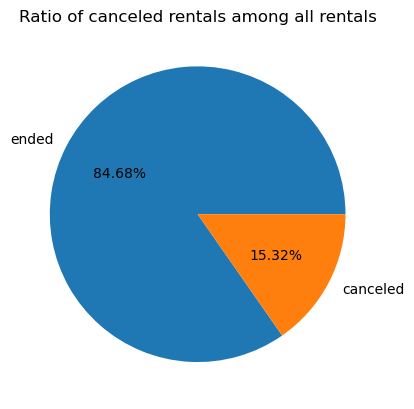

In [55]:
ratio_total_cancelation=plt.pie(raw_df['state'].value_counts(),
        autopct=lambda p: f"{p:.2f}%",
        labels=raw_df['state'].value_counts().index)
plt.title("Ratio of canceled rentals among all rentals")

Out of the 15,32% of missing data, which proportion has missing values for the variable `delay_at_checkout_in_minutes`?

The hypothesis we can verify is the following : rentals that have been canceled have no delay information because there was no checkin nor checkout. For that, we are going to see if there is a difference of missing data ratios according to the state of the rental (canceled vs ended).

**4.1.2. Ratio of missing data (delay) for CANCELED rentals**

In [56]:
total_canceled_rentals_df=raw_df[raw_df['state']=='canceled']
delay_canceled_nan_nb = total_canceled_rentals_df['delay_at_checkout_in_minutes'].isna().sum()
print(f"___ State of the rental: CANCELED ___\n\n{delay_canceled_nan_nb} missing delay values out of {len(total_canceled_rentals_df)}. \nThis represents {100*delay_canceled_nan_nb/len(total_canceled_rentals_df):.2f}% of all canceled rentals. ")

___ State of the rental: CANCELED ___

3264 missing delay values out of 3265. 
This represents 99.97% of all canceled rentals. 


**4.1.3. Ratio of missing data (delay) for ENDED rentals**

In [57]:
total_ended_rentals_df=raw_df[raw_df['state']=='ended']
delay_ended_nan_nb=total_ended_rentals_df['delay_at_checkout_in_minutes'].isna().sum()
print(f"___ State of the rental: ENDED ___\n\n{delay_ended_nan_nb} missing delay values out of {len(total_ended_rentals_df)}. \nThis represents {100*delay_ended_nan_nb/len(total_ended_rentals_df):.2f}% of all canceled rentals.")

___ State of the rental: ENDED ___

1700 missing delay values out of 18045. 
This represents 9.42% of all canceled rentals.


When a rental is canceled, 99.97% of delay information is missing. This strongly supports our hypothesis that missing delay data in canceled rentals is expected and meaningful, as no checkout actually occurred. Consequently, these missing values should not be removed.

For ended rentals, the proportion of missing delay values is much lower (9.42%). This likely reflects data quality issues rather than a structural absence of checkout. At this stage, we choose to retain these observations and apply filtering only when necessary for specific analyses.

Let's evaluate if the position of the rental (first rental or consecutives rentals) has an influence on that variable and its missing values.


### **4.2. Ratio of missing data according to rental position (first or consecutive)** ###

In [58]:
# Identify consecutive vs first rentals
is_consecutive = raw_df['previous_ended_rental_id'].notna()
is_first = raw_df['previous_ended_rental_id'].isna()

print("\nMissing delay rate:")
print(f"- First rentals: {raw_df[is_first]['delay_at_checkout_in_minutes'].isna().sum() / is_first.sum() * 100:.2f}%")
print(f"- Consecutive rentals: {raw_df[is_consecutive]['delay_at_checkout_in_minutes'].isna().sum() / is_consecutive.sum() * 100:.2f}%")


Missing delay rate:
- First rentals: 23.82%
- Consecutive rentals: 17.71%


We can observe a difference, we need to ckeck if it is statistically sgnificant to validate the hypothesis of an impact of the rental position (first or consecutive) on missing delay information:

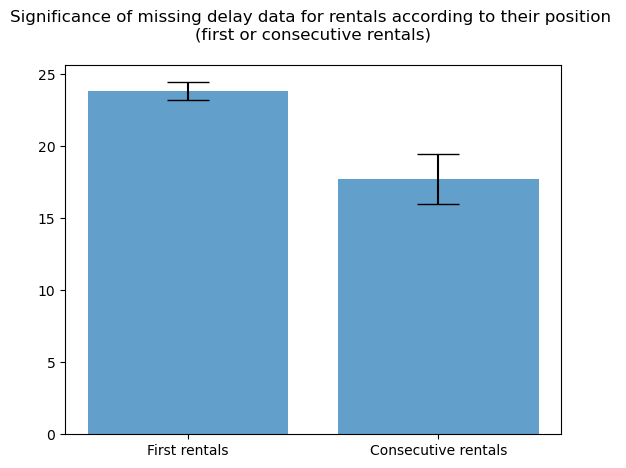

The p-value is: 0.000000


In [88]:
delay_missing = raw_df['delay_at_checkout_in_minutes'].isna()

# First rentals
first_total = is_first.sum()
first_missing = (is_first & delay_missing).sum()
first_rate = first_missing / first_total * 100

# Consecutive rentals
consec_total = is_consecutive.sum()
consec_missing = (is_consecutive & delay_missing).sum()
consec_rate = consec_missing / consec_total * 100

# Error margin calculation for a confidence interval of 95%
def margin_error(rate, n):
    p = rate / 100
    se = np.sqrt(p * (1 - p) / n)
    return 1.96 * se * 100

err1 = margin_error(first_rate, first_total)
err2 = margin_error(consec_rate, consec_total)

# Statistical test
table = [[first_total - first_missing, first_missing],
         [consec_total - consec_missing, consec_missing]]
chi2, p_value, _, _ = chi2_contingency(table)


plt.bar(['First rentals', 'Consecutive rentals'], [first_rate, consec_rate],
        yerr=[err1, err2], capsize=15,
        alpha=0.7)
plt.title("Significance of missing delay data for rentals according to their position \n(first or consecutive rentals)\n")
plt.show()

print(f"The p-value is: {p_value:.6f}")


The rental position has a significant importance on the number of missing delay data. First rentals have 6.11% extra missing information. 

Missing data for `delay_at_checkout_in_minutes` variable are kept so far because a large part of them carries meaning.

## **5. Analysis of cancellations** ##

We will now check which proportion of cancellations concerns risky rentals compare to first rentals to see if there is a difference. Indeed, we need to understand which part of cancellations is linked to delays and not to other reasons.

### **5.1. Ratios of cancellations** ###

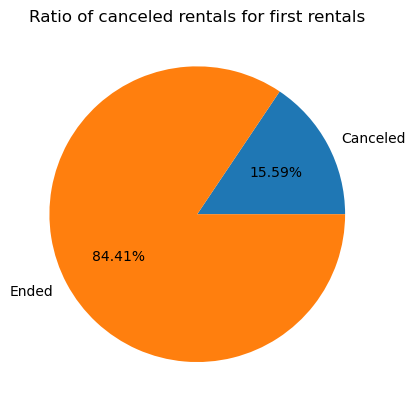

In [61]:
# Ratio of canceled rentals for first rentals:
state_first_rentals = pd.DataFrame({
    'State': ['Canceled','Ended'],
    'Count': [
        (only_first_rentals_df['state']=="canceled").sum(),
        (only_first_rentals_df['state']=="ended").sum()]},
        index=['Canceled','Ended'])
state_first_rentals['Percentage %'] = (state_first_rentals['Count'] / len(only_first_rentals_df) * 100).round(2)

plot=state_first_rentals.plot.pie(
    y='Percentage %',
    autopct=lambda p: f"{p:.2f}%",
    legend=False,
    labels=state_first_rentals.index,
    ylabel='',
    title="Ratio of canceled rentals for first rentals")


Out of all rentals, 15,59% have been canceled. We need to determine if they are linked to delays or to other reasons. To do so, let's calculate the same ratio "risky rentals" and compare it to this ratio.

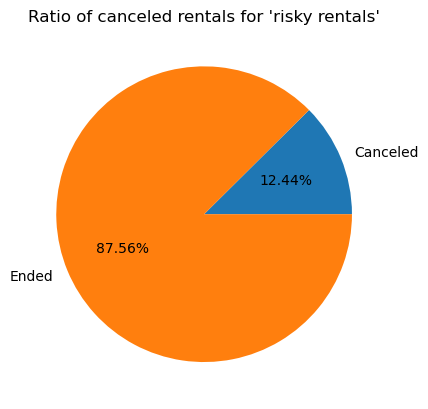

In [62]:
# Ratio of canceled rentals for cars with several rentals.
state_risky_rentals = pd.DataFrame({
    'State': ['Canceled','Ended'],
    'Count': [
        (risky_rentals_df['state']=="canceled").sum(),
        (risky_rentals_df['state']=="ended").sum()]},
        index=['Canceled','Ended'])
state_risky_rentals['Percentage %'] = (state_risky_rentals['Count'] / len(risky_rentals_df) * 100).round(2)

state_risky_rentals 
plot=state_risky_rentals.plot.pie(
    y='Percentage %',
    autopct=lambda p: f"{p:.2f}%",
    legend=False,
    labels=state_risky_rentals.index,
    ylabel='',
    title="Ratio of canceled rentals for 'risky rentals'")


The ratio of canceled rentals for consecutive rentals that can be impacted by a delay is not higher than for first rentals (even a bit lower) so the fact that rentals are part of consecutive rentals does not seem to increase the likeliness of cancellations. Let's select "risky rentals" that have been canceled to analyze them deeper. 

In [63]:
canceled_risky_rentals_df=risky_rentals_df[risky_rentals_df['state']=='canceled']
print( f"Out of all risky rentals ({len(risky_rentals_df)} rentals), {len(canceled_risky_rentals_df)} have been canceled.")

Out of all risky rentals (1841 rentals), 229 have been canceled.


In [64]:
ended_risky_rentals_df=risky_rentals_df[risky_rentals_df['state']=='ended']

### **5.2. Delay and time delta analysis** ###

_**5.2.1 Delay and time delta analysis of CANCELED risky rentals**_

Now that we have extracted all the risky rentals that have been canceled, let's check what proportion has a positive delay (negative delay means that the car has been checked out in advance).

In [65]:
# Is there available`delay_at_checkout_in_minutes' information for risky rentals?
canceled_risky_rentals_df["delay_at_checkout_in_minutes"].notna().sum()

0

We have no information about the delay at checkout for canceled risky rentals but we can check how long the planned time delta was between the consecutive rentals.

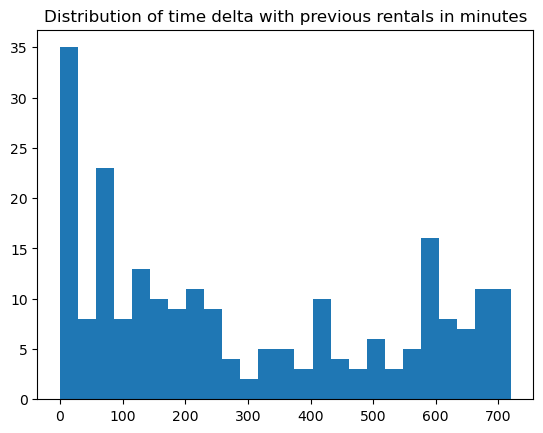

In [66]:
plt.hist(canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"],bins=25)
plt.title("Distribution of time delta with previous rentals in minutes")
plt.show()

In [67]:
canceled_min_time_delta=min(canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"])
canceled_max_time_delta=max(canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"])
print(f"The range of time delta with previous car is: {canceled_min_time_delta:.0f} to {canceled_max_time_delta:.0f} minutes (= {canceled_max_time_delta/60:.0f} hours).")

The range of time delta with previous car is: 0 to 720 minutes (= 12 hours).


In [68]:
# Statistical summary of delays for canceled rentals
canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"].describe()

count    229.000000
mean     294.890830
std      250.591601
min        0.000000
25%       60.000000
50%      210.000000
75%      570.000000
max      720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

In [69]:
canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"].value_counts().sort_index()

time_delta_with_previous_rental_in_minutes
0.0      35
30.0      8
60.0     23
90.0      8
120.0    13
150.0    10
180.0     9
210.0    11
240.0     9
270.0     4
300.0     2
330.0     5
360.0     5
390.0     3
420.0    10
450.0     4
480.0     3
510.0     6
540.0     3
570.0     5
600.0    16
630.0     8
660.0     7
690.0    11
720.0    11
Name: count, dtype: int64

One quarter of canceled risky rentals have a time delta with the previous rental of one hour or less and 35 rentals have no time delta at all which can be risky in case of a delay of the previous checkout.

_**5.2.2 Delay and time delta analysis of ENDED risky rentals**_

Let's do the same analysis for 'ended' risky rentals.

In [70]:
# Is there available`delay_at_checkout_in_minutes' information for risky rentals?
ended_risky_rentals_df["delay_at_checkout_in_minutes"].notna().sum()
print(f"Delay_at_checkout_in_minutes is available for: {ended_risky_rentals_df['delay_at_checkout_in_minutes'].notna().sum()} out of {len(ended_risky_rentals_df)}.")

Delay_at_checkout_in_minutes is available for: 1515 out of 1612.


This time, we do have information about the delay at checkout, we will analyze it now:

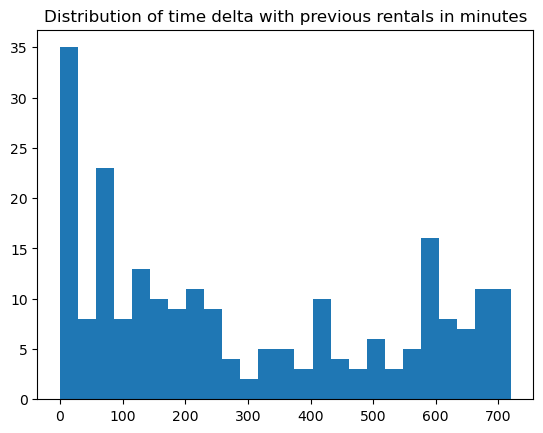

In [71]:
plt.hist(canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"],bins=25)
plt.title("Distribution of time delta with previous rentals in minutes")
plt.show()

In [72]:
canceled_min_time_delta=min(canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"])
canceled_max_time_delta=max(canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"])
print(f"The range of time delta with previous car is: {canceled_min_time_delta:.0f} to {canceled_max_time_delta:.0f} minutes (= {canceled_max_time_delta/60:.0f} hours).")

The range of time delta with previous car is: 0 to 720 minutes (= 12 hours).


In [73]:
# Statistical summary of delays for canceled rentals
canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"].describe()

count    229.000000
mean     294.890830
std      250.591601
min        0.000000
25%       60.000000
50%      210.000000
75%      570.000000
max      720.000000
Name: time_delta_with_previous_rental_in_minutes, dtype: float64

In [74]:
canceled_risky_rentals_df["time_delta_with_previous_rental_in_minutes"].value_counts().sort_index()

time_delta_with_previous_rental_in_minutes
0.0      35
30.0      8
60.0     23
90.0      8
120.0    13
150.0    10
180.0     9
210.0    11
240.0     9
270.0     4
300.0     2
330.0     5
360.0     5
390.0     3
420.0    10
450.0     4
480.0     3
510.0     6
540.0     3
570.0     5
600.0    16
630.0     8
660.0     7
690.0    11
720.0    11
Name: count, dtype: int64

One quarter of canceled risky rentals have a time delta with the previous rental of one hour or less and 35 rentals have no time delta at all which can be risky in case of a delay of the previous checkout.